# DeliveryGuard

## Delivery Failure Intelligence System

### Objective
Build a data-driven system that predicts delivery delay risk,
identifies the major factors contributing to delays, and eventually
provides actionable operational recommendations.

### Project Stage
01 - Data Exploration

In [1]:
import os

print(os.listdir("../data/raw"))

['India-Food-Delivery-Time-Prediction.txt']


In [3]:
file_path="../data/raw/India-Food-Delivery-Time-Prediction.txt"

with open(file_path,"r",encoding="utf-8" ) as file:
    for i in range (10):
        print(file.readline().strip())

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [1]:
file_path = "../data/raw/India-Food-Delivery-Time-Prediction.txt"

with open(file_path, "r", encoding="utf-8") as file:
    first_line = file.readline()

print(repr(first_line))

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [2]:
file_path = "../data/raw/India-Food-Delivery-Time-Prediction.txt"

with open(file_path, "rb") as file:
    sample = file.read(500)

print(sample)

b'[    {        "ID":"0x4607 ",        "Delivery_person_ID":"INDORES13DEL02 ",        "Delivery_person_Age":"37",        "Delivery_person_Ratings":"4.9",        "Restaurant_latitude":22.745049,        "Restaurant_longitude":75.892471,        "Delivery_location_latitude":22.765049,        "Delivery_location_longitude":75.912471,        "Order_Date":"19-03-2022",        "Time_Orderd":"11:33:33",        "Time_Order_picked":"11:45:29",        "Weatherconditions":"conditions Sunny",        "Road_traffi'


In [3]:
import os

file_size = os.path.getsize(file_path)

print(f"File size: {file_size / (1024 * 1024):.2f} MB")

File size: 30.05 MB


In [4]:
import pandas as pd

file_path = "../data/raw/India-Food-Delivery-Time-Prediction.txt"
df=pd.read_json(file_path)

print("Data set loaded successfully ")


Data set loaded successfully 


In [9]:
df.shape



(41953, 20)

In [10]:
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30


In [11]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [13]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

In [14]:
missing = df.isnull().sum()

missing_percentage= (missing / len(df)) *100
print(missing_percentage)

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            4.097442
Delivery_person_Ratings        4.202322
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Time_Orderd                    3.813792
Time_Order_picked              0.000000
Weatherconditions              0.000000
Road_traffic_density           0.000000
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.157176
Festival                       0.000000
City                           0.000000
Time_taken(min)                0.000000
dtype: float64


In [16]:
df[df['Delivery_person_Age'].isnull()].head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
41,0x4f0,MUMRES17DEL02,NaN,NaN,19.121999,72.908493,19.201999,72.988493,06-04-2022,None,18:36:55,conditions Cloudy,Medium,1,Drinks,scooter,1.0,No,Metropolitian,(min) 33
66,0xa9f,BANGRES13DEL01,NaN,NaN,12.935662,77.614130,12.975662,77.654130,11-03-2022,None,15:31:11,conditions NaN,NaN,1,Drinks,scooter,0.0,No,Metropolitian,(min) 19
110,0x6e2,VADRES06DEL01,NaN,NaN,22.312790,73.170283,22.422790,73.280283,02-04-2022,None,18:26:07,conditions NaN,NaN,3,Snack,electric_scooter,0.0,No,Metropolitian,(min) 25
129,0x1ec7,PUNERES05DEL03,NaN,NaN,18.543626,73.905101,18.573626,73.935101,09-03-2022,None,23:41:40,conditions Stormy,Low,2,Snack,scooter,0.0,No,NaN,(min) 19
162,0x1b58,JAPRES03DEL01,NaN,NaN,26.913483,75.803139,26.983483,75.873139,12-03-2022,None,17:50:59,conditions Sandstorms,Medium,0,Drinks,motorcycle,0.0,No,Metropolitian,(min) 43


In [17]:
df[["Delivery_person_Age", "Delivery_person_Ratings", "Time_Orderd"]].isnull().sum()

Delivery_person_Age        1719
Delivery_person_Ratings    1763
Time_Orderd                1600
dtype: int64

In [18]:
df[df["Delivery_person_Age"].isnull()][
    ["Delivery_person_Age", "Delivery_person_Ratings", "Time_Orderd"]
].isnull().sum()

Delivery_person_Age        1719
Delivery_person_Ratings    1719
Time_Orderd                1519
dtype: int64

In [19]:
age_missing = df["Delivery_person_Age"].isnull()

print("Total age-missing rows:", age_missing.sum())

print(
    "Rating also missing:",
    df.loc[age_missing, "Delivery_person_Ratings"].isnull().sum()
)

print(
    "Order time also missing:",
    df.loc[age_missing, "Time_Orderd"].isnull().sum()
)

Total age-missing rows: 1719
Rating also missing: 1719
Order time also missing: 1519


## Missing Data Finding

The dataset contains missing values in four columns:
- Delivery_person_Age: 1,719 (4.10%)
- Delivery_person_Ratings: 1,763 (4.20%)
- Time_Orderd: 1,600 (3.81%)
- multiple_deliveries: 905 (2.16%)

A further investigation showed that all 1,719 records with a missing
Delivery_person_Age also have a missing Delivery_person_Ratings value.
Additionally, 1,519 of these records (88.36%) have a missing Time_Orderd.

This suggests that the missing values may not be completely independent
of each other. We will investigate the pattern further before deciding
how to handle the missing values.

In [20]:
duplicate_rows = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


In [21]:
unique_ids = df["ID"].nunique()

total_rows = len(df)

print("Total rows:", total_rows)
print("Unique IDs:", unique_ids)

Total rows: 41953
Unique IDs: 41953


In [22]:
unique_couriers = df["Delivery_person_ID"].nunique()

print("Number of unique delivery persons:", unique_couriers)

Number of unique delivery persons: 1170


In [23]:
df["Road_traffic_density"].value_counts()

Road_traffic_density
Low        14200
Jam        13043
Medium     10084
High        4071
NaN          555
Name: count, dtype: int64

In [24]:
print(df["Road_traffic_density"].unique())

['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']


In [25]:
for value in df["Road_traffic_density"].unique():
    print(repr(value), type(value))

'High ' <class 'str'>
'Jam ' <class 'str'>
'Low ' <class 'str'>
'Medium ' <class 'str'>
'NaN ' <class 'str'>


In [26]:
categorical_columns = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

for column in categorical_columns:
    print("\n---", column, "---")
    print(df[column].unique())


--- Weatherconditions ---
['conditions Sunny' 'conditions Stormy' 'conditions Sandstorms'
 'conditions Cloudy' 'conditions Fog' 'conditions Windy' 'conditions NaN']

--- Road_traffic_density ---
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']

--- Type_of_order ---
['Snack ' 'Drinks ' 'Buffet ' 'Meal ']

--- Type_of_vehicle ---
['motorcycle ' 'scooter ' 'electric_scooter ' 'bicycle ']

--- Festival ---
['No ' 'Yes ' 'NaN ']

--- City ---
['Urban ' 'Metropolitian ' 'NaN ' 'Semi-Urban ']


In [27]:
for column in categorical_columns:
    nan_like = df[column].astype(str).str.contains("NaN", na=False).sum()
    print(column, ":", nan_like)

Weatherconditions : 569
Road_traffic_density : 555
Type_of_order : 0
Type_of_vehicle : 0
Festival : 215
City : 1114


In [28]:
print("Before:")
print(df["Road_traffic_density"].unique())

print("\nAfter strip():")
print(df["Road_traffic_density"].str.strip().unique())

Before:
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']

After strip():
['High' 'Jam' 'Low' 'Medium' 'NaN']


In [29]:
df_clean = df.copy()

print("Raw dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)

Raw dataset shape: (41953, 20)
Clean dataset shape: (41953, 20)


In [33]:
for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip()

In [34]:
for column in categorical_columns:
    print("\n---", column, "---")
    print(df_clean[column].unique())


--- Weatherconditions ---
['conditions Sunny' 'conditions Stormy' 'conditions Sandstorms'
 'conditions Cloudy' 'conditions Fog' 'conditions Windy' 'conditions NaN']

--- Road_traffic_density ---
['High' 'Jam' 'Low' 'Medium' 'NaN']

--- Type_of_order ---
['Snack' 'Drinks' 'Buffet' 'Meal']

--- Type_of_vehicle ---
['motorcycle' 'scooter' 'electric_scooter' 'bicycle']

--- Festival ---
['No' 'Yes' 'NaN']

--- City ---
['Urban' 'Metropolitian' 'NaN' 'Semi-Urban']


In [37]:
import numpy as np
fake_nan_columns = [
    "Road_traffic_density",
    "Festival",
    "City"
]

for column in fake_nan_columns:
    df_clean[column] = df_clean[column].replace("NaN", np.nan)

In [38]:
df_clean["Weatherconditions"] = (
    df_clean["Weatherconditions"]
    .replace("conditions NaN", np.nan)
)

In [39]:
df_clean[categorical_columns].isnull().sum()

Weatherconditions        569
Road_traffic_density     555
Type_of_order              0
Type_of_vehicle            0
Festival                 215
City                    1114
dtype: int64

In [40]:
df_clean["Delivery_person_Age"].describe()

count    40234.000000
mean        29.563330
std          5.812361
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

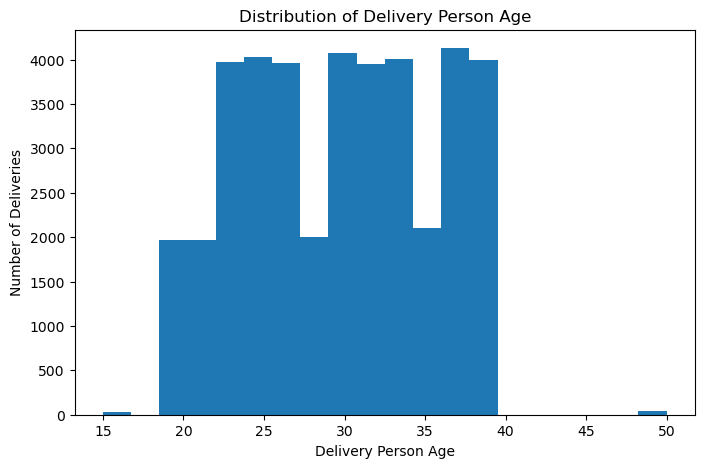

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_clean["Delivery_person_Age"].dropna(), bins=20)
plt.xlabel("Delivery Person Age")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Delivery Person Age")
plt.show()

In [42]:
df_clean["Delivery_person_Age"].value_counts().sort_index()

Delivery_person_Age
15.0      35
20.0    1964
21.0    1965
22.0    2029
23.0    1939
24.0    2044
25.0    1988
26.0    1988
27.0    1973
28.0    2004
29.0    2020
30.0    2050
31.0    1943
32.0    2010
33.0    2014
34.0    1995
35.0    2099
36.0    2083
37.0    2047
38.0    2020
39.0    1978
50.0      46
Name: count, dtype: int64

In [43]:
df_clean["Delivery_person_Ratings"].describe()

count    40190.000000
mean         4.632386
std          0.335541
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

In [44]:
df_clean["Delivery_person_Ratings"].value_counts().sort_index()

Delivery_person_Ratings
1.0      35
2.5      18
2.6      20
2.7      21
2.8      17
2.9      18
3.0       6
3.1      28
3.2      26
3.3      23
3.4      32
3.5     236
3.6     194
3.7     203
3.8     218
3.9     176
4.0     998
4.1    1323
4.2    1331
4.3    1301
4.4    1246
4.5    3067
4.6    6387
4.7    6528
4.8    6558
4.9    6468
5.0    3666
6.0      46
Name: count, dtype: int64

In [45]:
df_clean[df_clean["Delivery_person_Ratings"] == 6.0][
    ["Delivery_person_ID", "Delivery_person_Age",
     "Delivery_person_Ratings", "Time_taken(min)", "City"]
]

,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min),City
3283,BANGRES05DEL01,50.0,6.0,(min) 25,Urban
4315,HYDRES17DEL01,50.0,6.0,(min) 27,Metropolitian
4733,JAPRES08DEL01,50.0,6.0,(min) 20,Metropolitian
4909,BANGRES19DEL01,50.0,6.0,(min) 18,Metropolitian
5174,AGRRES13DEL02,50.0,6.0,(min) 20,Metropolitian
5867,JAPRES06DEL02,50.0,6.0,(min) 20,Urban
6457,MYSRES15DEL02,50.0,6.0,(min) 14,Metropolitian
8735,BANGRES010DEL01,50.0,6.0,(min) 17,Urban
8769,RANCHIRES13DEL01,50.0,6.0,(min) 32,Metropolitian
9291,MYSRES04DEL01,50.0,6.0,(min) 35,Metropolitian


In [46]:
df_clean[df_clean["Delivery_person_Age"] == 50][
    ["Delivery_person_Age", "Delivery_person_Ratings"]
].value_counts()

Delivery_person_Age  Delivery_person_Ratings
50.0                 6.0                        46
Name: count, dtype: int64

In [47]:
df_clean[df_clean["Delivery_person_Ratings"] == 6][
    ["Delivery_person_Age", "Delivery_person_Ratings"]
].value_counts()

Delivery_person_Age  Delivery_person_Ratings
50.0                 6.0                        46
Name: count, dtype: int64

In [48]:
data_quality_notes = {
    "categorical_whitespace": "Trailing whitespace found in categorical columns",
    "fake_missing_values": "NaN represented as strings in Weatherconditions, Road_traffic_density, Festival and City",
    "suspicious_age_rating": "46 records have Age=50 and Rating=6 simultaneously"
}

data_quality_notes

{'categorical_whitespace': 'Trailing whitespace found in categorical columns',
 'fake_missing_values': 'NaN represented as strings in Weatherconditions, Road_traffic_density, Festival and City',
 'suspicious_age_rating': '46 records have Age=50 and Rating=6 simultaneously'}

In [49]:
suspicious_rows = df_clean[
    (df_clean["Delivery_person_Age"] == 50) &
    (df_clean["Delivery_person_Ratings"] == 6)
]

print("Number of suspicious rows:", len(suspicious_rows))

print("\nMissing values in these rows:")
print(suspicious_rows.isnull().sum())

Number of suspicious rows: 46

Missing values in these rows:
ID                              0
Delivery_person_ID              0
Delivery_person_Age             0
Delivery_person_Ratings         0
Restaurant_latitude             0
Restaurant_longitude            0
Delivery_location_latitude      0
Delivery_location_longitude     0
Order_Date                      0
Time_Orderd                    46
Time_Order_picked               0
Weatherconditions              46
Road_traffic_density           46
Vehicle_condition               0
Type_of_order                   0
Type_of_vehicle                 0
multiple_deliveries             0
Festival                        0
City                            2
Time_taken(min)                 0
dtype: int64


In [50]:
df_clean["Delivery_person_Age"].replace(50, np.nan)

0        37.0
1        34.0
2        23.0
3        38.0
4        32.0
         ... 
41948    35.0
41949    30.0
41950    30.0
41951    20.0
41952    23.0
Name: Delivery_person_Age, Length: 41953, dtype: float64

In [52]:
suspicious_mask = (
    (df_clean["Delivery_person_Age"] == 50) &
    (df_clean["Delivery_person_Ratings"] == 6)
)

df_clean.loc[suspicious_mask, "Delivery_person_Age"] = np.nan
df_clean.loc[suspicious_mask, "Delivery_person_Ratings"] = np.nan

In [53]:
print("Missing Age:", df_clean["Delivery_person_Age"].isnull().sum())
print("Missing Ratings:", df_clean["Delivery_person_Ratings"].isnull().sum())

Missing Age: 1765
Missing Ratings: 1809


In [54]:
df_clean["multiple_deliveries"].value_counts(dropna=False).sort_index()

multiple_deliveries
0.0    12952
1.0    25928
2.0     1841
3.0      327
NaN      905
Name: count, dtype: int64

In [55]:
df_clean["Time_taken(min)"].head(10)

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
5    (min) 26
6    (min) 40
7    (min) 32
8    (min) 34
9    (min) 46
Name: Time_taken(min), dtype: object

In [56]:
df_clean["Time_taken(min)"] = df_clean["Time_taken(min)"].str.replace(
    "(min)", "", regex=False
)

In [57]:
df_clean["Time_taken(min)"].head()

0     24
1     33
2     26
3     21
4     30
Name: Time_taken(min), dtype: object

In [58]:
df_clean["Time_taken(min)"] = df_clean["Time_taken(min)"].astype(int)

In [59]:
print(df_clean["Time_taken(min)"].head())
print("Data type:", df_clean["Time_taken(min)"].dtype)

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64
Data type: int64


In [60]:
df_clean["Time_taken(min)"].describe()

count    41953.000000
mean        26.311539
std          9.380753
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

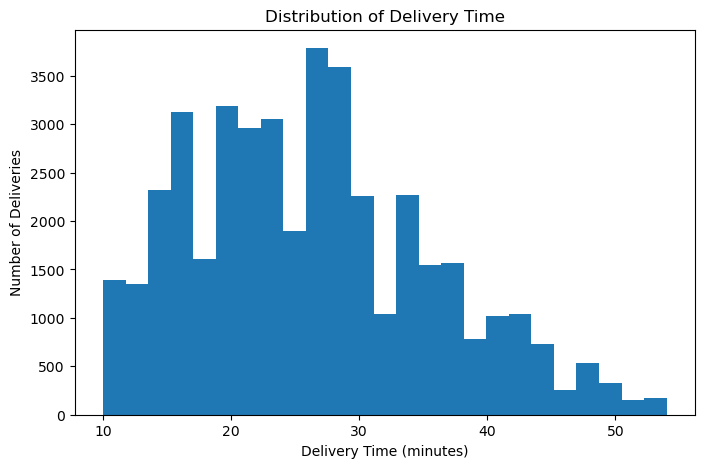

In [61]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Time_taken(min)"],
    bins=25
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Delivery Time")

plt.show()

In [62]:
df_clean.groupby("Road_traffic_density")

In [64]:
df_clean.groupby("Road_traffic_density")["Time_taken(min)"].mean()

Road_traffic_density
High      27.226480
Jam       31.183087
Low       21.279930
Medium    26.726497
Name: Time_taken(min), dtype: float64

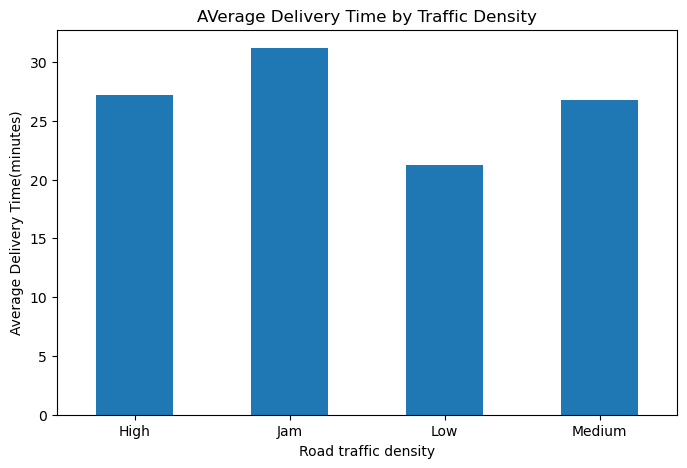

In [66]:
traffic_avg=(df_clean.groupby("Road_traffic_density")["Time_taken(min)"].mean())

traffic_avg.plot(kind="bar" , figsize=(8,5))

plt.xlabel("Road traffic density")
plt.ylabel("Average Delivery Time(minutes)")
plt.title("AVerage Delivery Time by Traffic Density")

plt.xticks(rotation=0)
plt.show()


In [72]:
import numpy as np

lat1=np.radians(df_clean["Restaurant_latitude"])
lon1=np.radians(df_clean["Restaurant_longitude"])

lat2=np.radians(df_clean["Delivery_location_latitude"])
lon2=np.radians(df_clean["Delivery_location_longitude"])

dlat=lat2-lat1

dlon=lon2-lon1

a=(
    np.sin(dlat/2) ** 2
    + np.cos(lat1) 
    * np.cos(lat2)
    * np.sin(dlon/2) ** 2
  )

c= 2 * np.arctan2(
    np.sqrt(a),
    np.sqrt(1-a)
)

df_clean["distance_km"] = 6371*c

df_clean["distance_km"].describe()


count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64

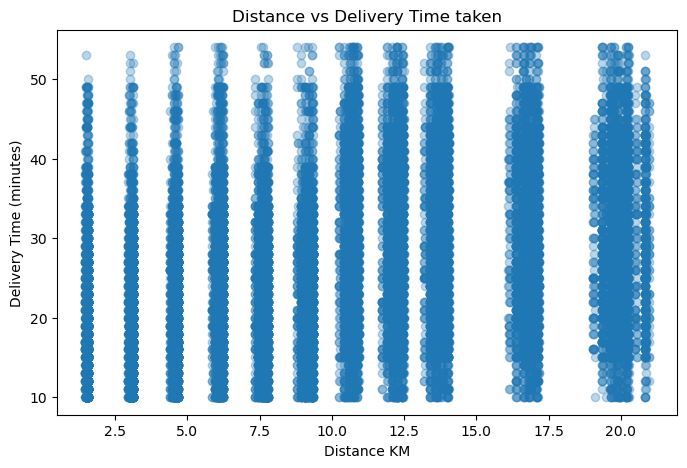

In [74]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_clean["distance_km"],
    df_clean["Time_taken(min)"],
    alpha=0.3
)

plt.xlabel("Distance KM")
plt.ylabel("Delivery Time (minutes)")
plt.title("Distance vs Delivery Time taken")
plt.show()

In [75]:
df_clean["distance_km"].corr(df_clean["Time_taken(min)"])

np.float64(0.32053867721056045)

In [78]:
df_clean["distance_category"]=pd.cut(
    df_clean["distance_km"],
    bins=[0,5,10,15,float("inf")],
    labels=["Short","Medium","Long","Very Long"]
)

In [80]:
df_clean["distance_category"].value_counts()

distance_category
Medium       11307
Short        11303
Long         11293
Very Long     8050
Name: count, dtype: int64

In [82]:
df_clean.groupby(
    ["distance_category", "Road_traffic_density"],
    observed=True
)["Time_taken(min)"].mean()

distance_category  Road_traffic_density
Short              High                    27.201960
                   Jam                     27.078033
                   Low                     19.555771
                   Medium                  23.076568
Medium             High                    27.246643
                   Jam                     27.193469
                   Low                     19.402127
                   Medium                  22.947616
Long               Jam                     33.478333
                   Low                     24.073403
                   Medium                  30.014138
Very Long          Jam                     33.543346
                   Low                     24.201932
                   Medium                  29.952467
Name: Time_taken(min), dtype: float64

In [87]:
traffic_distance = df_clean.pivot_table(
    index="distance_category",
    columns="Road_traffic_density",
    values="Time_taken(min)",
    aggfunc="mean",
    observed=True
)
traffic_distance

Road_traffic_density,High,Jam,Low,Medium
distance_category,,,,
Short,27.201960,27.078033,19.555771,23.076568
Medium,27.246643,27.193469,19.402127,22.947616
Long,NaN,33.478333,24.073403,30.014138
Very Long,NaN,33.543346,24.201932,29.952467


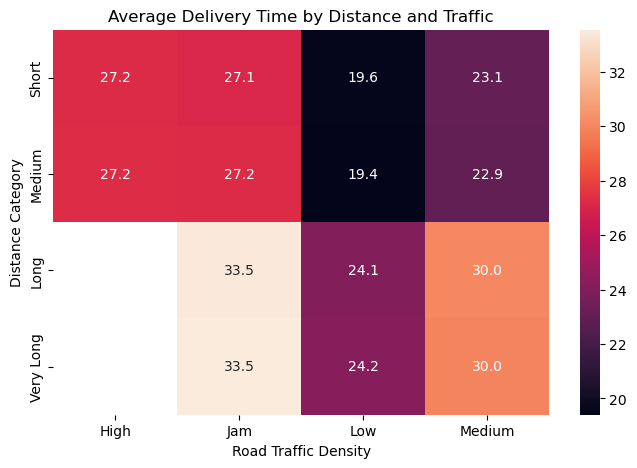

In [93]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
        traffic_distance,
        annot=True,
       fmt=".1f"
)

plt.title("Average Delivery Time by Distance and Traffic")
plt.xlabel("Road Traffic Density")
plt.ylabel("Distance Category")
plt.show()

In [94]:
weather_time=df_clean.groupby(
    "Weatherconditions",
    observed=True,
)["Time_taken(min)"].mean()

weather_time

Weatherconditions
conditions Cloudy        28.925995
conditions Fog           28.974330
conditions Sandstorms    25.880973
conditions Stormy        25.896759
conditions Sunny         21.897295
conditions Windy         26.128952
Name: Time_taken(min), dtype: float64

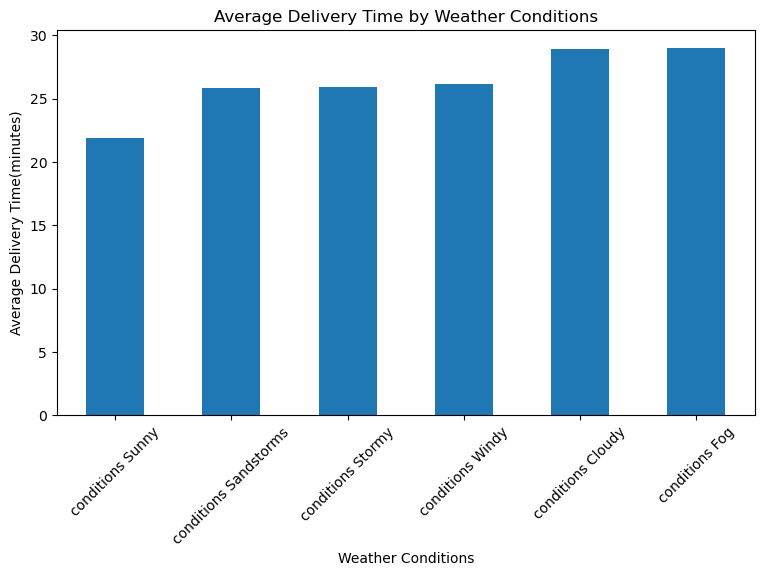

In [95]:
plt.figure(figsize=(9,5))

weather_time.sort_values().plot(kind="bar")

plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time(minutes)")
plt.title("Average Delivery Time by Weather Conditions")

plt.xticks(rotation=45)

plt.show()

In [96]:
multiple_delivery_time=df_clean.groupby(
    "multiple_deliveries",
    observed=True   
)["Time_taken(min)"].mean()

multiple_delivery_time

multiple_deliveries
0.0    22.896232
1.0    26.867132
2.0    40.450842
3.0    47.850153
Name: Time_taken(min), dtype: float64

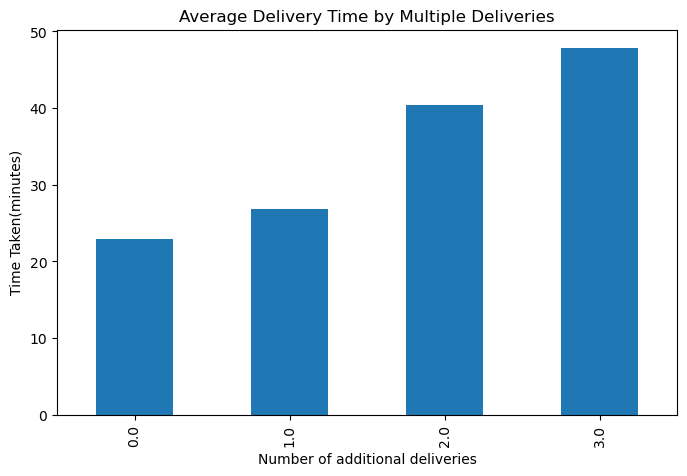

In [97]:
plt.figure(figsize=(8,5))

multiple_delivery_time.plot(kind="bar")

plt.title('Average Delivery Time by Multiple Deliveries')
plt.xlabel('Number of additional deliveries')
plt.ylabel('Time Taken(minutes)')

plt.show()

In [102]:
df_clean["Vehicle_condition"].value_counts().sort_index()

Vehicle_condition
0    13815
1    13851
2    13806
3      481
Name: count, dtype: int64

In [107]:
vehicle_time=df_clean.groupby(
    "Vehicle_condition",
    observed=True
)["Time_taken(min)"].mean()

vehicle_time

Vehicle_condition
0    30.091205
1    24.370659
2    24.479429
3    26.230769
Name: Time_taken(min), dtype: float64

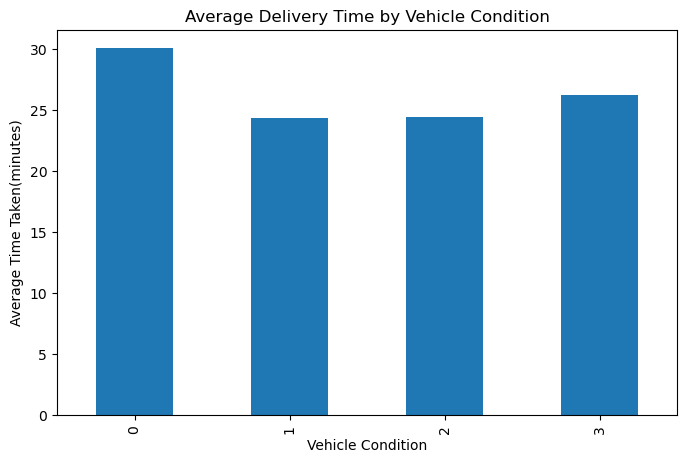

In [108]:
plt.figure(figsize=(8,5))

vehicle_time.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Average Time Taken(minutes)")

plt.show()

In [110]:
vehicle_type=df_clean.groupby(
    "Type_of_vehicle",
    observed=True
)["Time_taken(min)"].mean()

vehicle_type

Type_of_vehicle
bicycle             26.416667
electric_scooter    24.460208
motorcycle          27.609198
scooter             24.512153
Name: Time_taken(min), dtype: float64

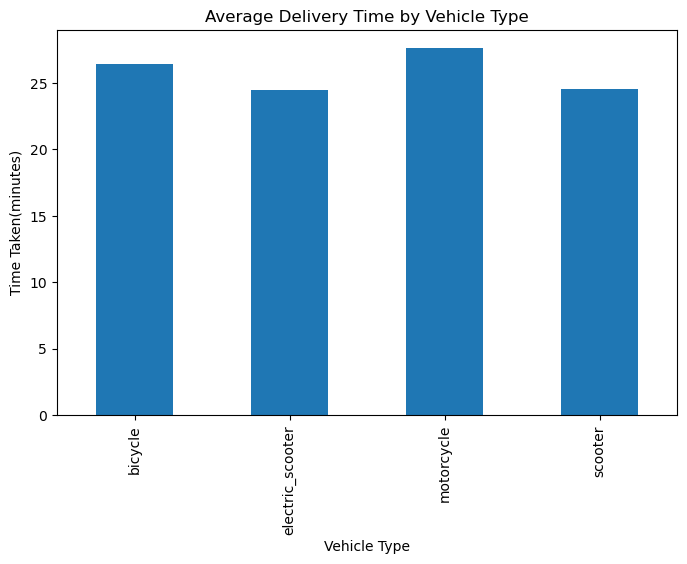

In [111]:
plt.figure(figsize=(8,5))

vehicle_type.plot(kind="bar")

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Time Taken(minutes)")

plt.show()

In [116]:
order_type_time=df_clean.groupby(
    "Type_of_order",
    observed=True
)["Time_taken(min)"].mean()

order_type_time

Type_of_order
Buffet    26.239873
Drinks    26.193873
Meal      26.486792
Snack     26.323568
Name: Time_taken(min), dtype: float64

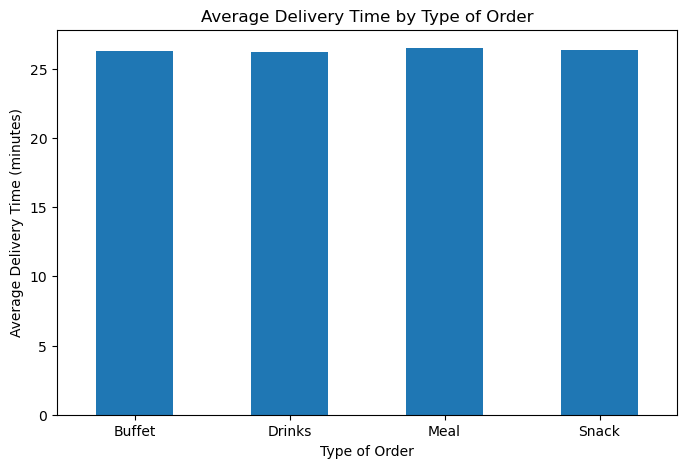

In [117]:
plt.figure(figsize=(8, 5))

order_type_time.plot(kind="bar")

plt.title("Average Delivery Time by Type of Order")
plt.xlabel("Type of Order")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=0)

plt.show()

In [118]:
city_time=df_clean.groupby(
        "City",
    observed=True
)["Time_taken(min)"].mean()

city_time

City
Metropolitian    27.321225
Semi-Urban       49.677852
Urban            23.024895
Name: Time_taken(min), dtype: float64

In [119]:
df_clean["City"].value_counts()

City
Metropolitian    31411
Urban             9279
Semi-Urban         149
Name: count, dtype: int64

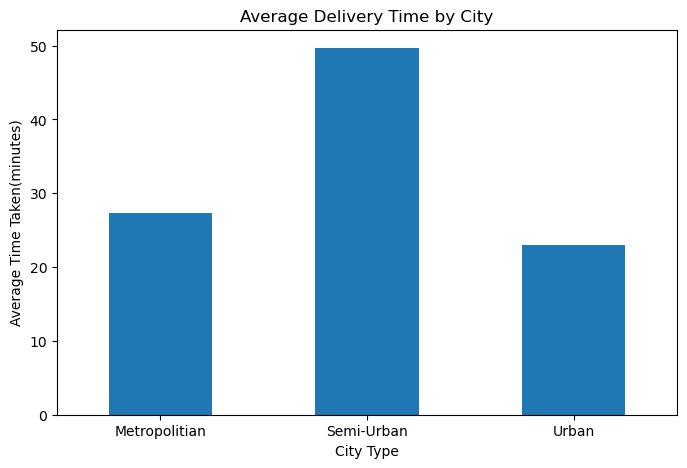

In [123]:
plt.figure(figsize=(8,5))

city_time.plot(kind="bar")

plt.title("Average Delivery Time by City")
plt.xlabel("City Type")
plt.ylabel("Average Time Taken(minutes)")

plt.xticks(rotation=0)

plt.show()

In [128]:
festival_time=df_clean.groupby(
    "Festival",
    observed=True
)["Time_taken(min)"].mean()

festival_time



Festival
No     26.006037
Yes    45.479319
Name: Time_taken(min), dtype: float64

In [127]:
df_clean["Festival"].value_counts()

Festival
No     40916
Yes      822
Name: count, dtype: int64

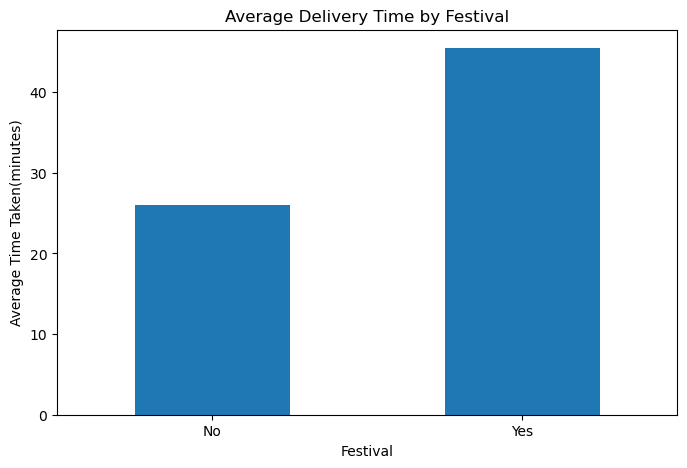

In [130]:
plt.figure(figsize=(8,5))

festival_time.plot(kind="bar")

plt.title("Average Delivery Time by Festival")
plt.xlabel("Festival")
plt.ylabel("Average Time Taken(minutes)")
plt.xticks(rotation=0)
plt.show()

In [132]:
df_clean["Order_Date"] = pd.to_datetime(
    df_clean["Order_Date"],
    format="%d-%m-%Y"
)

In [133]:
df_clean["Order_Date"].head()


0   2022-03-19
1   2022-03-25
2   2022-03-19
3   2022-04-05
4   2022-03-26
Name: Order_Date, dtype: datetime64[ns]

In [134]:
df_clean["Order_Month"] = df_clean["Order_Date"].dt.month

df_clean["Order_Month"].value_counts().sort_index()

Order_Month
2     6016
3    29972
4     5965
Name: count, dtype: int64

In [141]:
monthly_time = df_clean.groupby(
    "Order_Month",
    observed=True
)["Time_taken(min)"].mean()

print(monthly_time)

Order_Month
2    26.516622
3    26.305352
4    26.135792
Name: Time_taken(min), dtype: float64


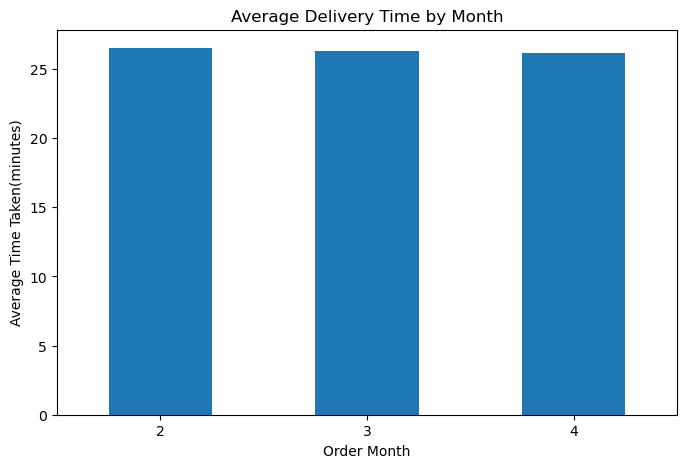

In [144]:
plt.figure(figsize=(8,5))

monthly_time.plot(kind="bar")

plt.title("Average Delivery Time by Month")
plt.xlabel("Order Month")
plt.ylabel("Average Time Taken(minutes)")
plt.xticks(rotation=0)

plt.show()

In [146]:
df_clean["Order_Day"]=df_clean["Order_Date"].dt.day_name()

In [148]:
df_clean["Order_Day"].value_counts()

Order_Day
Wednesday    6552
Friday       6408
Tuesday      5884
Thursday     5841
Saturday     5810
Sunday       5736
Monday       5722
Name: count, dtype: int64

Order_Day
Friday       26.822566
Monday       26.226669
Saturday     25.973150
Sunday       26.457113
Thursday     25.284369
Tuesday      25.434568
Wednesday    27.761752
Name: Time_taken(min), dtype: float64


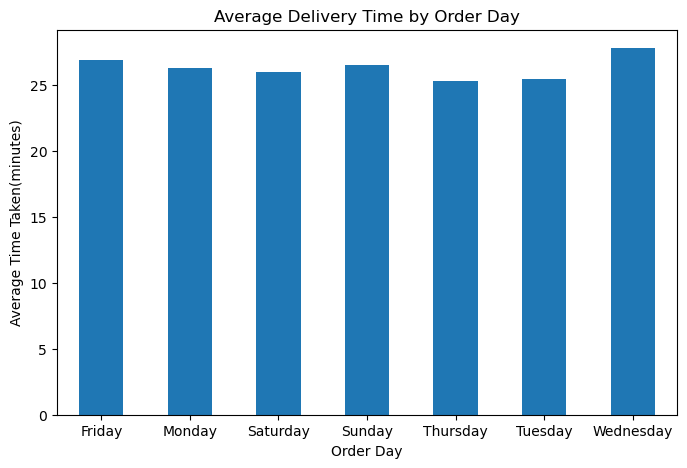

In [151]:
day_time=df_clean.groupby(
    "Order_Day",
    observed=True
)["Time_taken(min)"].mean()

print(day_time)

plt.figure(figsize=(8,5))

day_time.plot(kind="bar")
plt.title("Average Delivery Time by Order Day")
plt.xlabel("Order Day")
plt.ylabel("Average Time Taken(minutes)")

plt.xticks(rotation=0)

plt.show()

In [156]:
df_clean["Time_Order_picked"].head()

0    11:45:29
1    19:51:49
2     8:48:47
3    18:12:52
4    13:45:36
Name: Time_Order_picked, dtype: object

In [153]:
df_clean["Time_Order_picked"].dtype

dtype('O')

In [157]:
df_clean["Time_Order_picked"]=pd.to_datetime(
    df_clean["Time_Order_picked"],
    format="%H:%M:%S"
)

In [159]:
df_clean["Time_Order_picked"].dtype

dtype('<M8[ns]')

In [160]:
df_clean["Order_Picked_Hour"] = df_clean["Time_Order_picked"].dt.hour

In [161]:
df_clean["Order_Picked_Hour"].head()

0    11
1    19
2     8
3    18
4    13
Name: Order_Picked_Hour, dtype: int32

In [162]:
df_clean["Order_Picked_Hour"].value_counts().sort_index()

Order_Picked_Hour
0     1212
8     1377
9     1886
10    1937
11    1827
12    1074
13     736
14     749
15     829
16     712
17    3394
18    4392
19    4292
20    4410
21    4455
22    4385
23    4286
Name: count, dtype: int64

In [164]:
def get_period(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 20:
        return "Evening"
    else:
        return "Night"

df_clean["Order_Period"] = df_clean["Order_Picked_Hour"].apply(get_period)

In [165]:
df_clean["Order_Period"].value_counts()

Order_Period
Evening      16488
Night        14338
Morning       7027
Afternoon     4100
Name: count, dtype: int64

In [166]:
period_time = df_clean.groupby(
    "Order_Period",
    observed=True
)["Time_taken(min)"].mean()

print(period_time)

Order_Period
Afternoon    25.922683
Evening      29.074478
Morning      20.975381
Night        25.860720
Name: Time_taken(min), dtype: float64


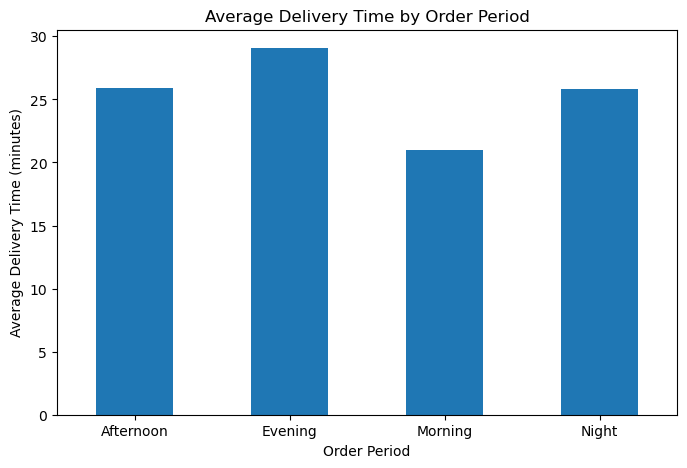

In [167]:
plt.figure(figsize=(8, 5))

period_time.plot(kind="bar")

plt.title("Average Delivery Time by Order Period")
plt.xlabel("Order Period")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=0)

plt.show()

In [9]:
import os

os.getcwd()

'C:\\Users\\KIIT0001\\DeliveryGuard\\notebook'

In [10]:
import os

os.listdir(r"C:\Users\KIIT0001\DeliveryGuard")

['.ipynb_checkpoints', 'data', 'notebook']

In [11]:
import os

os.listdir(r"C:\Users\KIIT0001\DeliveryGuard\data")

['raw']

In [12]:
import os

os.listdir(r"C:\Users\KIIT0001\DeliveryGuard\data\raw")

['India-Food-Delivery-Time-Prediction.txt']

In [1]:
import pandas as pd

In [1]:
import pandas as pd

In [2]:
file_path = r"C:\Users\KIIT0001\DeliveryGuard\data\raw\India-Food-Delivery-Time-Prediction.txt"

In [3]:
with open(file_path, "r", encoding="utf-8") as f:
    first_line = f.readline()

print(first_line)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [4]:
import pandas as pd

file_path = r"C:\Users\KIIT0001\DeliveryGuard\data\raw\India-Food-Delivery-Time-Prediction.txt"

df = pd.read_json(file_path)

In [5]:
df.shape

(41953, 20)

In [6]:
with open(file_path, "r", encoding="utf-8") as f:
    print(f.read(200))

[    {        "ID":"0x4607 ",        "Delivery_person_ID":"INDORES13DEL02 ",        "Delivery_person_Age":"37",        "Delivery_person_Ratings":"4.9",        "Restaurant_latitude":22.745049,        "


In [7]:
df_clean=df.copy()

In [8]:
df_clean.shape

(41953, 20)

In [9]:
df_clean.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  object 
 1   Delivery_person_ID           41953 non-null  object 
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  object 
 9   Time_Orderd                  40353 non-null  object 
 10  Time_Order_picked            41953 non-null  object 
 11  Weatherconditions            41953 non-null  object 
 12  Road_traffic_density         41953 non-null  object 
 13  Vehicle_conditio

In [11]:
df_clean["Time_taken(min)"] = (
    df_clean["Time_taken(min)"]
    .str.replace("(min) ", "", regex=False)
    .astype(int)
)

In [12]:
df_clean["Time_taken(min)"].head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64

In [13]:
df_clean["Order_Date"] = pd.to_datetime(
    df_clean["Order_Date"],
    format="%d-%m-%Y"
)

In [14]:
df_clean["Order_Date"].head()

0   2022-03-19
1   2022-03-25
2   2022-03-19
3   2022-04-05
4   2022-03-26
Name: Order_Date, dtype: datetime64[ns]

In [15]:
df_clean["Time_Orderd"].head(10)

0    11:33:33
1    19:45:37
2     8:32:58
3    18:03:58
4    13:34:16
5    21:23:28
6    19:19:19
7    17:29:18
8    20:56:37
9    21:59:01
Name: Time_Orderd, dtype: object

In [16]:
df_clean["Time_Orderd"] = pd.to_datetime(
    df_clean["Time_Orderd"],
    format="%H:%M:%S",
    errors="coerce"
)

In [17]:
df_clean["Time_Orderd"].head()

0   1900-01-01 11:33:33
1   1900-01-01 19:45:37
2   1900-01-01 08:32:58
3   1900-01-01 18:03:58
4   1900-01-01 13:34:16
Name: Time_Orderd, dtype: datetime64[ns]

In [18]:
df_clean["Time_Orderd"].dtype

dtype('<M8[ns]')

In [19]:
df_clean["Order_Hour"] = df_clean["Time_Orderd"].dt.hour

In [20]:
df_clean["Order_Hour"].value_counts().sort_index()

Order_Hour
0.0      443
8.0     1660
9.0     1793
10.0    1820
11.0    1802
12.0     839
13.0     722
14.0     728
15.0     793
16.0     650
17.0    3907
18.0    4140
19.0    4234
20.0    4199
21.0    4305
22.0    4200
23.0    4118
Name: count, dtype: int64

In [22]:
df_clean.groupby("Order_Hour")["Time_taken(min)"].mean().round(2)

Order_Hour
0.0     22.04
8.0     19.65
9.0     19.54
10.0    19.48
11.0    26.36
12.0    26.87
13.0    27.52
14.0    27.35
15.0    23.24
16.0    23.09
17.0    27.44
18.0    27.26
19.0    30.75
20.0    31.22
21.0    31.08
22.0    23.36
23.0    22.44
Name: Time_taken(min), dtype: float64

In [26]:
import matplotlib.pyplot as plt

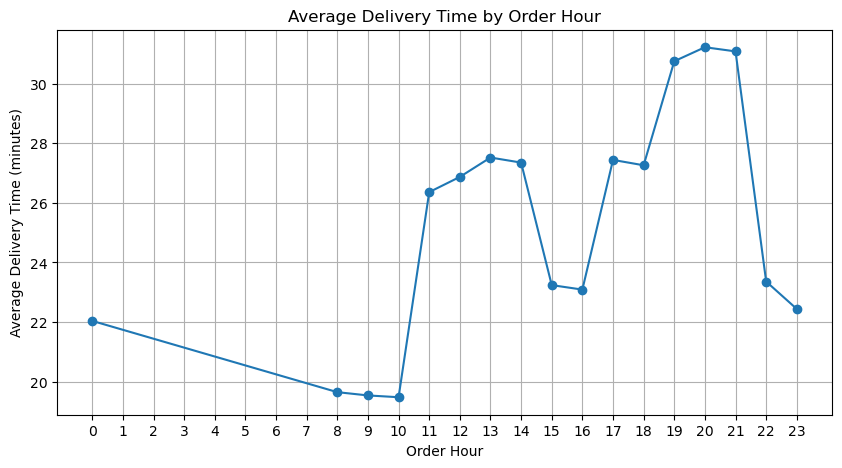

In [27]:
hourly_delivery = (
    df_clean.groupby("Order_Hour")["Time_taken(min)"]
    .mean()
    .round(2)
)

hourly_delivery.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Average Delivery Time by Order Hour"
)

plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [28]:
df_clean["Time_Orderd"].isna().sum()

np.int64(1600)

In [29]:
df_clean.groupby(
    df_clean["Time_Orderd"].isna()
)["Time_taken(min)"].mean()

Time_Orderd
False    26.312641
True     26.283750
Name: Time_taken(min), dtype: float64

In [31]:
df_clean[df_clean["Time_Orderd"].isna()][
    ["Weatherconditions","Road_traffic_density","Festival","City"]
].isna().sum()

Weatherconditions       0
Road_traffic_density    0
Festival                0
City                    0
dtype: int64

In [32]:
df_clean[df_clean["Time_Orderd"].isna()][
    ["Weatherconditions", "Road_traffic_density", "Festival", "City"]
].head(10)

,Weatherconditions,Road_traffic_density,Festival,City
41,conditions Cloudy,Medium,No,Metropolitian
66,conditions NaN,NaN,No,Metropolitian
110,conditions NaN,NaN,No,Metropolitian
129,conditions Stormy,Low,No,NaN
162,conditions Sandstorms,Medium,No,Metropolitian
228,conditions NaN,NaN,Yes,Urban
264,conditions Stormy,Jam,No,Urban
280,conditions Fog,Jam,No,Metropolitian
319,conditions NaN,NaN,No,Metropolitian
324,conditions Sunny,Low,Yes,Metropolitian


In [33]:
missing_time = df_clean["Time_Orderd"].isna()

for col in ["Weatherconditions", "Road_traffic_density", "Festival", "City"]:
    count = df_clean.loc[missing_time, col].astype(str).str.strip().str.endswith("NaN").sum()
    print(col, ":", count)

Weatherconditions : 569
Road_traffic_density : 555
Festival : 9
City : 55


In [34]:
df_clean["Weatherconditions"] = (
    df_clean["Weatherconditions"]
    .replace("conditions NaN", pd.NA)
)

In [35]:
df_clean["Weatherconditions"].isna().sum()

np.int64(569)

In [36]:
df_clean["Road_traffic_density"] = (
    df_clean["Road_traffic_density"]
    .str.strip()
    .replace("NaN", pd.NA)
)

In [37]:
df_clean["Road_traffic_density"].isna().sum()

np.int64(555)

In [38]:
df_clean["Festival"] = (
    df_clean["Festival"]
    .str.strip()
    .replace("NaN", pd.NA)
)

In [39]:
df_clean["Festival"].isna().sum()

np.int64(215)

In [40]:
df_clean["City"] = (
    df_clean["City"]
    .str.strip()
    .replace("NaN", pd.NA)
)

In [41]:
df_clean["City"].isna().sum()

np.int64(1114)

In [42]:
df_clean[
    ["Weatherconditions", "Road_traffic_density", "Festival", "City"]
].isna().sum()

Weatherconditions        569
Road_traffic_density     555
Festival                 215
City                    1114
dtype: int64

In [43]:
df_clean["Type_of_order"] = df_clean["Type_of_order"].str.strip()

df_clean["Type_of_vehicle"] = df_clean["Type_of_vehicle"].str.strip()

In [44]:
print(df_clean["Type_of_order"].unique())
print(df_clean["Type_of_vehicle"].unique())

['Snack' 'Drinks' 'Buffet' 'Meal']
['motorcycle' 'scooter' 'electric_scooter' 'bicycle']


In [45]:
df_clean.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
Order_Hour                     1600
dtype: int64

In [46]:
df_clean[
    (df_clean["Delivery_person_Age"] == 50) &
    (df_clean["Delivery_person_Ratings"] == 6)
].shape

(46, 21)

In [47]:
df_clean[
    (df_clean["Delivery_person_Age"] == 50) &
    (df_clean["Delivery_person_Ratings"] == 6)
][[
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Time_Orderd",
    "Weatherconditions",
    "Road_traffic_density",
    "Festival",
    "City",
    "multiple_deliveries",
    "Time_taken(min)"
]].head(10)

,Delivery_person_Age,Delivery_person_Ratings,Time_Orderd,Weatherconditions,Road_traffic_density,Festival,City,multiple_deliveries,Time_taken(min)
3283,50.0,6.0,NaT,<NA>,<NA>,No,Urban,0.0,25
4315,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,0.0,27
4733,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,1.0,20
4909,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,1.0,18
5174,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,1.0,20
5867,50.0,6.0,NaT,<NA>,<NA>,No,Urban,0.0,20
6457,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,1.0,14
8735,50.0,6.0,NaT,<NA>,<NA>,No,Urban,1.0,17
8769,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,1.0,32
9291,50.0,6.0,NaT,<NA>,<NA>,No,Metropolitian,1.0,35


In [48]:
df_clean["Suspicious_Age_Rating"] = (
    (df_clean["Delivery_person_Age"] == 50) &
    (df_clean["Delivery_person_Ratings"] == 6)
)

In [49]:
df_clean["Suspicious_Age_Rating"].value_counts()

Suspicious_Age_Rating
False    41907
True        46
Name: count, dtype: int64

In [50]:
df_clean.groupby("Suspicious_Age_Rating")["Time_taken(min)"].mean()

Suspicious_Age_Rating
False    26.315532
True     22.673913
Name: Time_taken(min), dtype: float64

In [51]:
df_clean.loc[
    df_clean["Suspicious_Age_Rating"],
    ["Delivery_person_Age", "Delivery_person_Ratings",
     "Time_Orderd", "Weatherconditions",
     "Road_traffic_density", "Festival", "City"]
].isna().sum()

Delivery_person_Age         0
Delivery_person_Ratings     0
Time_Orderd                46
Weatherconditions          46
Road_traffic_density       46
Festival                    0
City                        2
dtype: int64

In [52]:
df_clean.loc[
    df_clean["Suspicious_Age_Rating"],
    "Time_taken(min)"
].describe()

count    46.000000
mean     22.673913
std       7.791889
min      11.000000
25%      17.000000
50%      20.000000
75%      28.000000
max      41.000000
Name: Time_taken(min), dtype: float64

In [53]:
missing_percent = (
    df_clean.isna().mean() * 100
).sort_values(ascending=False)

missing_percent


Delivery_person_Ratings        4.202322
Delivery_person_Age            4.097442
Order_Hour                     3.813792
Time_Orderd                    3.813792
City                           2.655352
multiple_deliveries            2.157176
Weatherconditions              1.356280
Road_traffic_density           1.322909
Festival                       0.512478
Delivery_person_ID             0.000000
Restaurant_longitude           0.000000
Restaurant_latitude            0.000000
ID                             0.000000
Delivery_location_latitude     0.000000
Vehicle_condition              0.000000
Time_Order_picked              0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
Time_taken(min)                0.000000
Suspicious_Age_Rating          0.000000
dtype: float64

In [54]:
print("Median Age:", df_clean["Delivery_person_Age"].median())
print("Median Rating:", df_clean["Delivery_person_Ratings"].median())

Median Age: 30.0
Median Rating: 4.7


In [56]:
df_clean["Delivery_person_Age"]=(
    df_clean["Delivery_person_Age"].fillna(
        df_clean["Delivery_person_Age"].median()
    )
)

In [57]:
df_clean["Delivery_person_Ratings"] = (
    df_clean["Delivery_person_Ratings"].fillna(
        df_clean["Delivery_person_Ratings"].median()
    )
)

In [58]:
print("Missing Age:", df_clean["Delivery_person_Age"].isna().sum())
print("Missing Rating:", df_clean["Delivery_person_Ratings"].isna().sum())

Missing Age: 0
Missing Rating: 0


In [59]:
df_clean["City"].value_counts(dropna=False)

City
Metropolitian    31411
Urban             9279
<NA>              1114
Semi-Urban         149
Name: count, dtype: int64

In [60]:
df_clean["City"] = df_clean["City"].fillna("Metropolitian")

In [61]:
df_clean["City"].isna().sum()

np.int64(0)

In [63]:
df_clean["multiple_deliveries"].value_counts(dropna=False).sort_index()

multiple_deliveries
0.0    12952
1.0    25928
2.0     1841
3.0      327
NaN      905
Name: count, dtype: int64

In [64]:
df_clean["multiple_deliveries"]=(
    df_clean["multiple_deliveries"].fillna(1.0)
)

In [65]:
df_clean["multiple_deliveries"].isna().sum()

np.int64(0)

In [66]:
df_clean["Weatherconditions"].value_counts(dropna=False)

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
<NA>                      569
Name: count, dtype: int64

In [67]:
df_clean["Weatherconditions"] = (
    df_clean["Weatherconditions"].fillna("conditions Fog")
)


In [68]:
df_clean["Weatherconditions"].isna().sum()

np.int64(0)

In [69]:
df_clean["Road_traffic_density"].value_counts(dropna=False)

Road_traffic_density
Low       14200
Jam       13043
Medium    10084
High       4071
<NA>        555
Name: count, dtype: int64

In [70]:
df_clean["Road_traffic_density"]=(
    df_clean['Road_traffic_density'].fillna("Low")
)

In [71]:
df_clean["Road_traffic_density"].isna().sum()

np.int64(0)

In [72]:
df_clean["Festival"].value_counts(dropna=False)

Festival
No      40916
Yes       822
<NA>      215
Name: count, dtype: int64

In [73]:
df_clean["Festival"] = df_clean["Festival"].fillna("No")

In [74]:
df_clean["Festival"].isna().sum()

np.int64(0)

In [75]:
df_clean.isna().sum().sort_values(ascending=False)

Order_Hour                     1600
Time_Orderd                    1600
Delivery_person_Age               0
Delivery_person_Ratings           0
ID                                0
Delivery_person_ID                0
Restaurant_longitude              0
Restaurant_latitude               0
Delivery_location_longitude       0
Delivery_location_latitude        0
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Order_Date                        0
Vehicle_condition                 0
Type_of_order                     0
multiple_deliveries               0
Type_of_vehicle                   0
Festival                          0
City                              0
Time_taken(min)                   0
Suspicious_Age_Rating             0
dtype: int64

In [77]:
df_clean.dtypes

ID                                     object
Delivery_person_ID                     object
Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_Orderd                    datetime64[ns]
Time_Order_picked                      object
Weatherconditions                      object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                   float64
Festival                               object
City                                   object
Time_taken(min)                         int64
Order_Hour                            float64
Suspicious_Age_Rating             

In [78]:
df_clean["Time_Order_picked"]=pd.to_datetime(
    df_clean["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

In [79]:
df_clean[["Time_Orderd", "Time_Order_picked", "Order_Hour"]].dtypes

Time_Orderd          datetime64[ns]
Time_Order_picked    datetime64[ns]
Order_Hour                  float64
dtype: object

In [80]:
df_clean["Order_Picked_Hour"] = df_clean["Time_Order_picked"].dt.hour

In [81]:
df_clean["Order_Picked_Hour"].value_counts().sort_index()

Order_Picked_Hour
0     1212
8     1377
9     1886
10    1937
11    1827
12    1074
13     736
14     749
15     829
16     712
17    3394
18    4392
19    4292
20    4410
21    4455
22    4385
23    4286
Name: count, dtype: int64

In [82]:
avg_delivery_by_pickup_hour = (
    df_clean.groupby("Order_Picked_Hour")["Time_taken(min)"]
    .mean()
    .round(2)
)

avg_delivery_by_pickup_hour

Order_Picked_Hour
0     22.31
8     19.59
9     19.54
10    19.49
11    25.08
12    27.03
13    27.62
14    27.64
15    23.80
16    23.16
17    27.28
18    27.25
19    30.16
20    31.22
21    31.15
22    24.80
23    22.45
Name: Time_taken(min), dtype: float64

In [83]:
def get_period(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 20:
        return "Evening"
    else:
        return "Night"

In [84]:
df_clean["Order_Period"] = df_clean["Order_Picked_Hour"].apply(get_period)

In [85]:
df_clean["Order_Period"].value_counts()

Order_Period
Evening      16488
Night        14338
Morning       7027
Afternoon     4100
Name: count, dtype: int64

In [86]:
avg_delivery_by_period = (
    df_clean.groupby("Order_Period")["Time_taken(min)"]
    .mean()
    .round(2)
)

avg_delivery_by_period

Order_Period
Afternoon    25.92
Evening      29.07
Morning      20.98
Night        25.86
Name: Time_taken(min), dtype: float64

In [87]:
df_clean["Preparation_Time"] = (
    df_clean["Time_Order_picked"] - df_clean["Time_Orderd"]
)

In [88]:
df_clean["Preparation_Time"].describe()

count                          40353
mean     -1 days +23:43:57.748221942
std        0 days 03:09:47.294231384
min                -1 days +00:00:30
25%                  0 days 00:05:31
50%                  0 days 00:09:17
75%                  0 days 00:13:08
max                  0 days 00:19:53
Name: Preparation_Time, dtype: object

In [89]:
(df_clean["Preparation_Time"] < pd.Timedelta(0)).sum()

np.int64(794)

In [90]:
negative_mask = df_clean["Preparation_Time"] < pd.Timedelta(0)

df_clean.loc[negative_mask, "Preparation_Time"] += pd.Timedelta(days=1)

In [91]:
(df_clean["Preparation_Time"] < pd.Timedelta(0)).sum()

np.int64(0)

In [92]:
df_clean["Preparation_Time"].describe()

count                        40353
mean     0 days 00:12:17.785393898
std      0 days 01:03:23.071194488
min                0 days 00:00:00
25%                0 days 00:05:47
50%                0 days 00:09:30
75%                0 days 00:13:16
max                0 days 23:59:59
Name: Preparation_Time, dtype: object

In [93]:
df_clean[df_clean["Preparation_Time"] > pd.Timedelta(hours=2)][
    ["Order_Date", "Time_Orderd", "Time_Order_picked", "Preparation_Time"]
].head(20)

,Order_Date,Time_Orderd,Time_Order_picked,Preparation_Time
32,2022-02-11,1900-01-01 13:40:46,1900-01-01 13:40:35,0 days 23:59:49
1713,2022-03-21,1900-01-01 22:40:29,1900-01-01 22:40:27,0 days 23:59:58
2455,2022-03-23,1900-01-01 00:00:47,1900-01-01 00:00:12,0 days 23:59:25
2918,2022-02-17,1900-01-01 17:25:11,1900-01-01 17:25:05,0 days 23:59:54
3312,2022-03-07,1900-01-01 15:05:42,1900-01-01 15:05:29,0 days 23:59:47
3761,2022-03-11,1900-01-01 21:55:40,1900-01-01 21:55:23,0 days 23:59:43
3803,2022-03-01,1900-01-01 22:35:08,1900-01-01 22:35:06,0 days 23:59:58
4975,2022-03-02,1900-01-01 20:35:23,1900-01-01 20:35:05,0 days 23:59:42
5399,2022-03-10,1900-01-01 21:25:38,1900-01-01 21:25:36,0 days 23:59:58
5817,2022-02-13,1900-01-01 18:45:17,1900-01-01 18:45:12,0 days 23:59:55


In [95]:
(df_clean["Preparation_Time"] > pd.Timedelta(hours=23)).sum()

np.int64(79)

In [96]:
df_clean.drop(columns=["Preparation_Time"], inplace=True)

In [97]:
order_seconds = (
    df_clean["Time_Orderd"].dt.hour * 3600
    + df_clean["Time_Orderd"].dt.minute * 60
    + df_clean["Time_Orderd"].dt.second
)

pickup_seconds = (
    df_clean["Time_Order_picked"].dt.hour * 3600
    + df_clean["Time_Order_picked"].dt.minute * 60
    + df_clean["Time_Order_picked"].dt.second
)

In [98]:
preparation_seconds = pickup_seconds - order_seconds

In [99]:
(preparation_seconds < 0).sum()


np.int64(794)

In [100]:
preparation_seconds[preparation_seconds < 0].describe()

count      794.000000
mean    -77195.099496
std      25671.405196
min     -86370.000000
25%     -85863.000000
50%     -85643.000000
75%     -85492.500000
max         -1.000000
dtype: float64

In [101]:
preparation_seconds[preparation_seconds < 0].between(-300, -1).sum()

np.int64(79)

In [102]:
df_clean.loc[
    preparation_seconds.between(-300, -1),
    ["Time_Orderd", "Time_Order_picked"]
].head(20)

,Time_Orderd,Time_Order_picked
32,1900-01-01 13:40:46,1900-01-01 13:40:35
1713,1900-01-01 22:40:29,1900-01-01 22:40:27
2455,1900-01-01 00:00:47,1900-01-01 00:00:12
2918,1900-01-01 17:25:11,1900-01-01 17:25:05
3312,1900-01-01 15:05:42,1900-01-01 15:05:29
3761,1900-01-01 21:55:40,1900-01-01 21:55:23
3803,1900-01-01 22:35:08,1900-01-01 22:35:06
4975,1900-01-01 20:35:23,1900-01-01 20:35:05
5399,1900-01-01 21:25:38,1900-01-01 21:25:36
5817,1900-01-01 18:45:17,1900-01-01 18:45:12


In [103]:
preparation_seconds[preparation_seconds <= -300].count()

np.int64(715)

In [104]:
preparation_seconds[preparation_seconds <= -300].describe()

count      715.000000
mean    -85722.524476
std        250.367305
min     -86370.000000
25%     -85897.000000
50%     -85675.000000
75%     -85543.500000
max     -85248.000000
dtype: float64

In [105]:
preparation_seconds.loc[preparation_seconds <= -300] += 86400

In [106]:
preparation_seconds[preparation_seconds < 0].count()

np.int64(79)

In [107]:
preparation_seconds.loc[
    preparation_seconds.between(-300, -1)
] = pd.NA

In [108]:
preparation_seconds[preparation_seconds < 0].count()

np.int64(0)

In [109]:
df_clean["Preparation_Time_min"] = preparation_seconds / 60

In [110]:
df_clean["Preparation_Time_min"].describe()

count    40274.000000
mean         9.496432
std          4.555391
min          0.000000
25%          5.766667
50%          9.483333
75%         13.233333
max         19.883333
Name: Preparation_Time_min, dtype: float64

In [111]:
(df_clean["Preparation_Time_min"] == 0).sum()

np.int64(5)

In [112]:
df_clean["Preparation_Time_min"].sort_values(ascending=False).head(10)

4072     19.883333
28722    19.816667
27892    19.733333
1611     19.616667
14563    19.583333
1879     19.583333
9458     19.583333
1715     19.550000
2697     19.533333
13900    19.533333
Name: Preparation_Time_min, dtype: float64

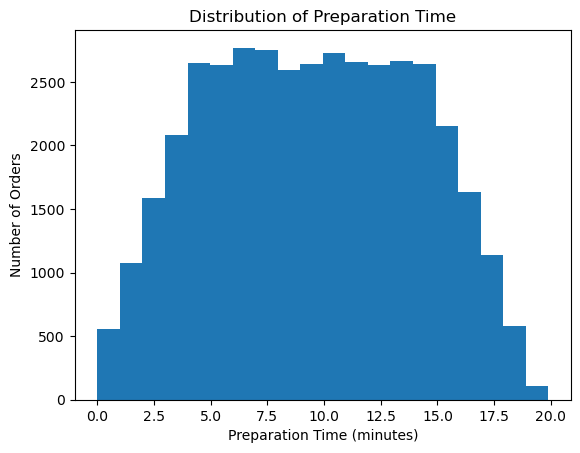

In [113]:
import matplotlib.pyplot as plt

df_clean["Preparation_Time_min"].dropna().plot(
    kind="hist",
    bins=20
)

plt.xlabel("Preparation Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Preparation Time")
plt.show()

In [114]:
df_clean[["Preparation_Time_min", "Time_taken(min)"]].corr()

,Preparation_Time_min,Time_taken(min)
Preparation_Time_min,1.000000,-0.006701
Time_taken(min),-0.006701,1.000000


In [115]:
df_clean.groupby(
    pd.cut(df_clean["Preparation_Time_min"], bins=5)
)["Time_taken(min)"].mean()

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_29716\2284851540.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(


Preparation_Time_min
(-0.0199, 3.977]    26.617182
(3.977, 7.953]      26.253009
(7.953, 11.93]      26.267433
(11.93, 15.907]     26.292765
(15.907, 19.883]    26.227036
Name: Time_taken(min), dtype: float64

In [116]:
df_clean["Preparation_Time_min"].isna().sum()

np.int64(1679)

In [117]:
df_clean.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)',
 'Order_Hour',
 'Suspicious_Age_Rating',
 'Order_Picked_Hour',
 'Order_Period',
 'Preparation_Time_min']

In [118]:
df_clean.dtypes

ID                                     object
Delivery_person_ID                     object
Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_Orderd                    datetime64[ns]
Time_Order_picked              datetime64[ns]
Weatherconditions                      object
Road_traffic_density                   object
Vehicle_condition                       int64
Type_of_order                          object
Type_of_vehicle                        object
multiple_deliveries                   float64
Festival                               object
City                                   object
Time_taken(min)                         int64
Order_Hour                            float64
Suspicious_Age_Rating             

In [119]:
df_clean.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken(min)                   0
Order_Hour                     1600
Suspicious_Age_Rating             0
Order_Picked_Hour                 0
Order_Period                      0
Preparation_Time_min           1679
dtype: int64

In [120]:
import os

os.makedirs(
    r"C:\Users\KIIT0001\DeliveryGuard\data\processed",
    exist_ok=True
)

print("Processed folder is ready.")

Processed folder is ready.


In [121]:
df_clean.to_csv(
    r"C:\Users\KIIT0001\DeliveryGuard\data\processed\deliveryguard_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [122]:
df_clean["Order_Month"] = df_clean["Order_Date"].dt.month

In [123]:
df_clean[["Order_Date", "Order_Month"]].head()

,Order_Date,Order_Month
0,2022-03-19,3
1,2022-03-25,3
2,2022-03-19,3
3,2022-04-05,4
4,2022-03-26,3


In [124]:
df_clean.groupby("Order_Month")["Time_taken(min)"].mean()

Order_Month
2    26.516622
3    26.305352
4    26.135792
Name: Time_taken(min), dtype: float64

In [125]:
df_clean["Order_Day"] = df_clean["Order_Date"].dt.day_name()

In [126]:
df_clean[["Order_Date", "Order_Day"]].head()

,Order_Date,Order_Day
0,2022-03-19,Saturday
1,2022-03-25,Friday
2,2022-03-19,Saturday
3,2022-04-05,Tuesday
4,2022-03-26,Saturday


In [127]:
df_clean.groupby("Order_Day")["Time_taken(min)"].mean()

Order_Day
Friday       26.822566
Monday       26.226669
Saturday     25.973150
Sunday       26.457113
Thursday     25.284369
Tuesday      25.434568
Wednesday    27.761752
Name: Time_taken(min), dtype: float64

In [128]:
df_clean.to_csv(
    r"C:\Users\KIIT0001\DeliveryGuard\data\processed\deliveryguard_cleaned.csv",
    index=False
)

In [129]:
df_clean.shape

(41953, 27)

In [130]:
df_clean.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken(min)                   0
Order_Hour                     1600
Suspicious_Age_Rating             0
Order_Picked_Hour                 0
Order_Period                      0
Preparation_Time_min           1679
Order_Month                       0
Order_Day                         0
dtype: int64

In [131]:
df_clean.duplicated().sum()

np.int64(0)

In [132]:
df_clean["Time_taken(min)"].describe()

count    41953.000000
mean        26.311539
std          9.380753
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

In [133]:
df_clean.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)',
 'Order_Hour',
 'Suspicious_Age_Rating',
 'Order_Picked_Hour',
 'Order_Period',
 'Preparation_Time_min',
 'Order_Month',
 'Order_Day']

In [134]:
import numpy as np

In [135]:
lat1 = np.radians(df_clean["Restaurant_latitude"])
lon1 = np.radians(df_clean["Restaurant_longitude"])

lat2 = np.radians(df_clean["Delivery_location_latitude"])
lon2 = np.radians(df_clean["Delivery_location_longitude"])

dlat = lat2 - lat1
dlon = lon2 - lon1

In [136]:
a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df_clean["distance_km"] = 6371 * c

In [137]:
df_clean["distance_km"].describe()

count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64

In [138]:
df_clean.shape, df_clean.columns.tolist()

((41953, 28),
 ['ID',
  'Delivery_person_ID',
  'Delivery_person_Age',
  'Delivery_person_Ratings',
  'Restaurant_latitude',
  'Restaurant_longitude',
  'Delivery_location_latitude',
  'Delivery_location_longitude',
  'Order_Date',
  'Time_Orderd',
  'Time_Order_picked',
  'Weatherconditions',
  'Road_traffic_density',
  'Vehicle_condition',
  'Type_of_order',
  'Type_of_vehicle',
  'multiple_deliveries',
  'Festival',
  'City',
  'Time_taken(min)',
  'Order_Hour',
  'Suspicious_Age_Rating',
  'Order_Picked_Hour',
  'Order_Period',
  'Preparation_Time_min',
  'Order_Month',
  'Order_Day',
  'distance_km'])

In [139]:
y = df_clean["Time_taken(min)"]

In [140]:
y.head()

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64

In [141]:
X = df_clean.drop(
    columns=[
        "ID",
        "Delivery_person_ID",
        "Order_Date",
        "Time_Orderd",
        "Time_Order_picked",
        "Time_taken(min)"
    ]
)

In [142]:
X.shape

(41953, 22)

In [144]:
X.dtypes

Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Order_Hour                     float64
Suspicious_Age_Rating             bool
Order_Picked_Hour                int32
Order_Period                    object
Preparation_Time_min           float64
Order_Month                      int32
Order_Day                       object
distance_km                    float64
dtype: object

In [145]:
categorical_cols = X.select_dtypes(include="object").columns

categorical_cols

Index(['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City', 'Order_Period', 'Order_Day'],
      dtype='object')

In [146]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

Categorical columns: 8
Numerical columns: 14


In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [148]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [150]:
print(X_train.shape)
print(X_test.shape)

(33562, 22)
(8391, 22)


In [151]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [152]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(33562, 48)
(8391, 48)


In [153]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [154]:
y_pred = model.predict(X_test_processed)

y_pred[:10]

array([27.31, 13.77, 29.7 , 23.28, 35.89, 23.66, 20.77, 21.08, 36.16,
       18.68])

In [155]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 3.202194017399595
RMSE: 4.063588120000556
R² Score: 0.8083391820777001


In [156]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False)

feature_importance.head(15)

num__Delivery_person_Ratings                0.197848
num__multiple_deliveries                    0.117959
cat__Road_traffic_density_Low               0.102786
num__distance_km                            0.102126
num__Delivery_person_Age                    0.088053
cat__Weatherconditions_conditions Sunny     0.069999
num__Vehicle_condition                      0.068905
cat__Weatherconditions_conditions Fog       0.044565
cat__Weatherconditions_conditions Cloudy    0.042451
num__Preparation_Time_min                   0.024327
cat__Road_traffic_density_Medium            0.016091
num__Delivery_location_longitude            0.013647
num__Delivery_location_latitude             0.013021
num__Restaurant_longitude                   0.012685
num__Restaurant_latitude                    0.011903
dtype: float64

<Axes: title={'center': 'Top 10 Feature Importances'}>

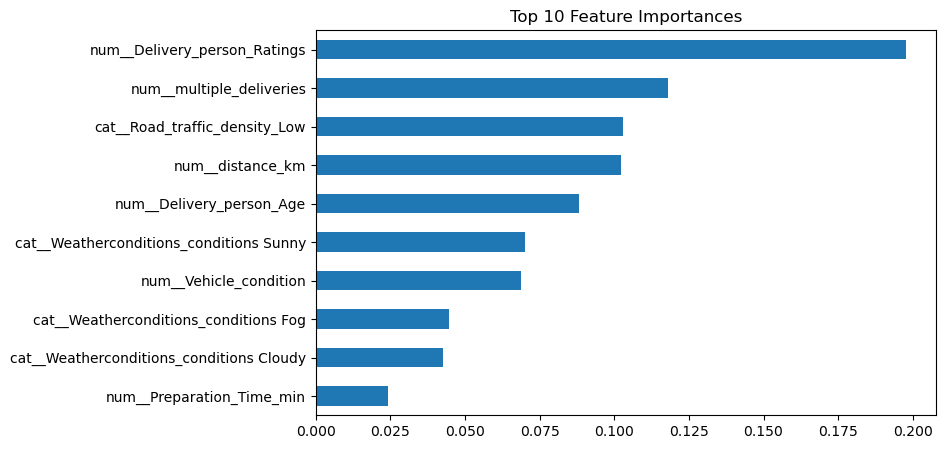

In [157]:
feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 Feature Importances"
)

In [158]:
from sklearn.ensemble import GradientBoostingRegressor

In [160]:
from sklearn.impute import SimpleImputer

In [161]:
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols
        )
    ]
)

In [162]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(33562, 48)
(8391, 48)


In [163]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

GradientBoostingRegressor(random_state=42)

In [164]:
gb_pred = gb_model.predict(X_test_processed)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MAE: 3.6045521928988373
Gradient Boosting RMSE: 4.532091944504814
Gradient Boosting R²: 0.7615971750718843


In [165]:
rf_model_300 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model_300.fit(X_train_processed, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [166]:
rf_model_300.fit(X_train_processed, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [167]:
rf300_pred = rf_model_300.predict(X_test_processed)

In [168]:
rf300_mae = mean_absolute_error(y_test, rf300_pred)
rf300_rmse = np.sqrt(mean_squared_error(y_test, rf300_pred))
rf300_r2 = r2_score(y_test, rf300_pred)

print("MAE:", rf300_mae)
print("RMSE:", rf300_rmse)
print("R²:", rf300_r2)

MAE: 3.1935581774123065
RMSE: 4.039747539742322
R²: 0.8105814867587549


In [169]:
feature_importance_300 = pd.Series(
    rf_model_300.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False)

feature_importance_300.head(15)

num__Delivery_person_Ratings                0.198432
num__multiple_deliveries                    0.117203
cat__Road_traffic_density_Low               0.102999
num__distance_km                            0.101994
num__Delivery_person_Age                    0.089648
cat__Weatherconditions_conditions Sunny     0.069589
num__Vehicle_condition                      0.069342
cat__Weatherconditions_conditions Fog       0.044734
cat__Weatherconditions_conditions Cloudy    0.042738
num__Preparation_Time_min                   0.021815
cat__Road_traffic_density_Medium            0.016748
num__Delivery_location_longitude            0.013919
num__Delivery_location_latitude             0.013381
num__Restaurant_longitude                   0.012825
num__Restaurant_latitude                    0.012129
dtype: float64

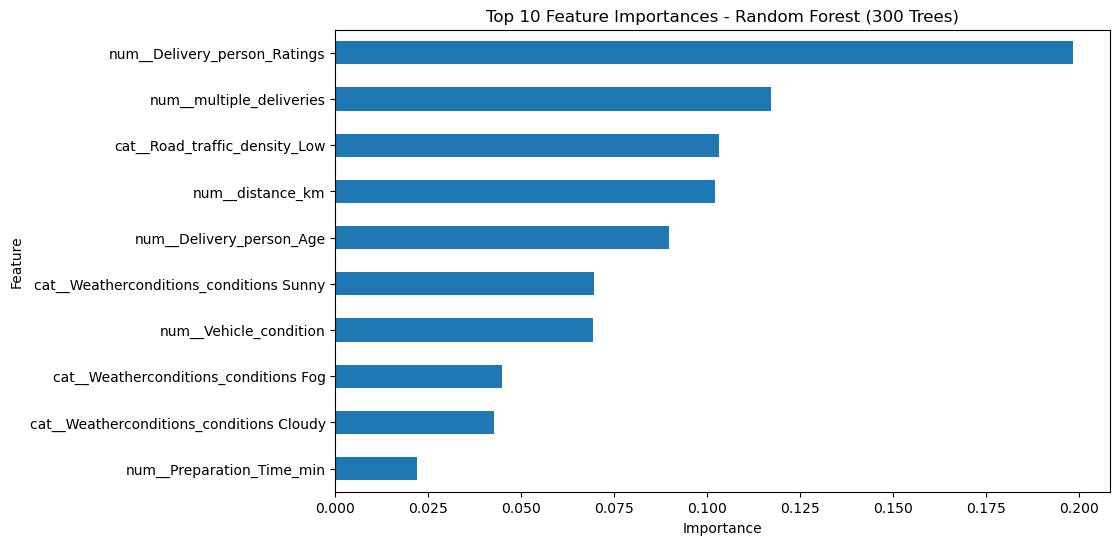

In [170]:
top10_importance = feature_importance_300.head(10).sort_values()

top10_importance.plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Feature Importances - Random Forest (300 Trees)"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [171]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [150],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.7, 1.0]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

In [172]:
rf_search.fit(X_train_processed, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 15, 20, None],
                                        'max_features': [0.7, 1.0],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [150]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [173]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV MAE:")
print(-rf_search.best_score_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 15}

Best CV MAE:
3.1861782723919725


In [174]:
tuned_pred = rf_search.best_estimator_.predict(X_test_processed)

In [175]:
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned Random Forest")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

Tuned Random Forest
MAE: 3.136627130963181
RMSE: 3.949248666500042
R²: 0.8189731753698339


In [176]:
residuals = y_test - tuned_pred

print(residuals.describe())

count    8391.000000
mean       -0.069116
std         3.948879
min       -17.895354
25%        -2.789039
50%        -0.187097
75%         2.544044
max        24.178737
Name: Time_taken(min), dtype: float64


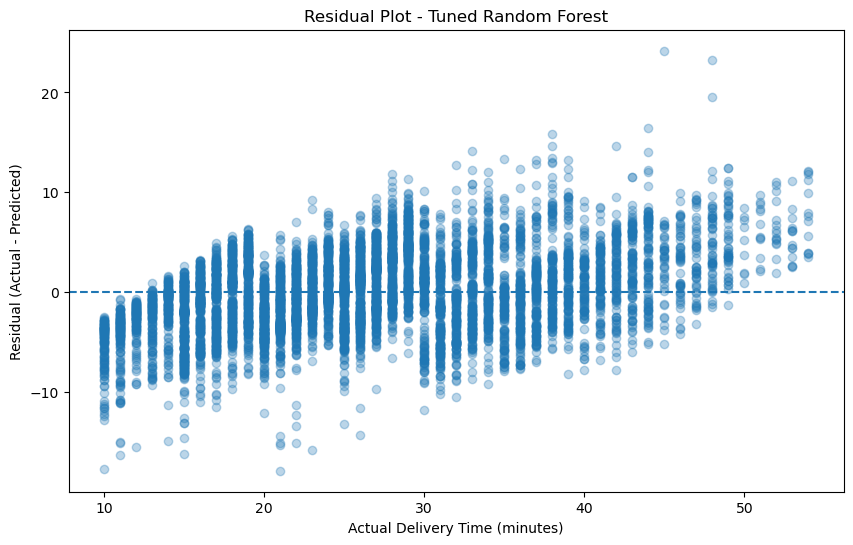

In [177]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, residuals, alpha=0.3)

plt.axhline(0, linestyle="--")

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Tuned Random Forest")

plt.show()

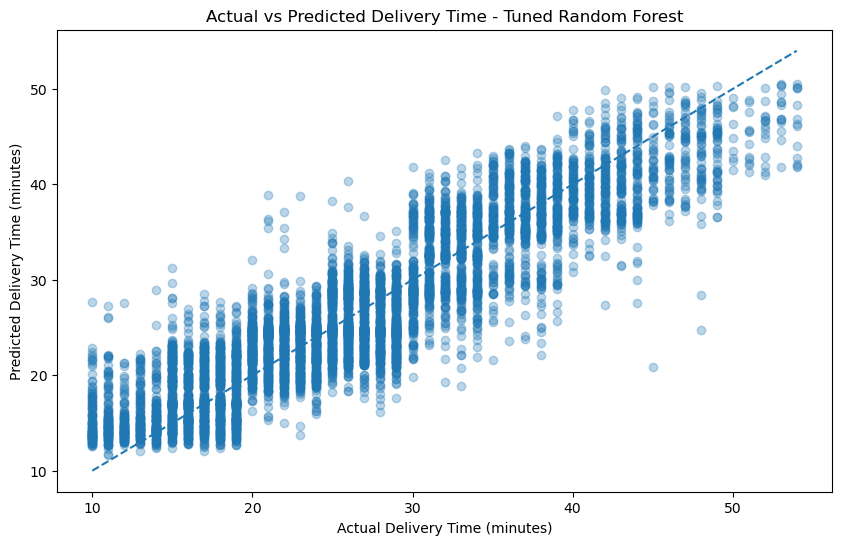

In [178]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, tuned_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time - Tuned Random Forest")

plt.show()

In [179]:
rf_search.best_estimator_

RandomForestRegressor(max_depth=15, max_features=0.7, n_estimators=150,
                      n_jobs=-1, random_state=42)

In [180]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_search.best_estimator_)
])

In [182]:
final_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Vehicle_condition',
       'multiple_deliveries', 'Order_Hour', 'Suspicious_Age_Rating',
       'Order_P...
       'distance_km'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Weatherconditions', 'Road_traffic_density', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City', 'Order_Period', 'Order_Day'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=15, max_features=0.7,
                                       n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [183]:
final_pred= final_pipeline.predict(X_test)

In [184]:
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("Final Pipeline")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R²:", final_r2)

Final Pipeline
MAE: 3.136627130963181
RMSE: 3.949248666500042
R²: 0.8189731753698339


In [185]:
import joblib

model_path = r"C:\Users\KIIT0001\DeliveryGuard\models\deliveryguard_model.pkl"

joblib.dump(final_pipeline, model_path)

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\KIIT0001\\DeliveryGuard\\models\\deliveryguard_model.pkl'

In [186]:
import os

os.makedirs(
    r"C:\Users\KIIT0001\DeliveryGuard\models",
    exist_ok=True
)

print("Models folder is ready!")

Models folder is ready!


In [187]:
joblib.dump(final_pipeline, model_path)

print("Model saved successfully!")

Model saved successfully!


In [188]:
loaded_pipeline = joblib.load(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [189]:
loaded_pred = loaded_pipeline.predict(X_test)

print("First 10 predictions:")
print(loaded_pred[:10])

First 10 predictions:
[27.44774348 14.03181167 30.73343157 23.46373806 36.63189636 23.68882494
 20.48433142 21.94925433 36.56201893 18.2084022 ]


In [190]:
sample_order = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_order)

print("Predicted delivery time:", round(prediction[0], 2), "minutes")
print("Actual delivery time:", y_test.iloc[0], "minutes")

Predicted delivery time: 27.45 minutes
Actual delivery time: 21 minutes


In [191]:
import sklearn
import joblib

print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.6.1
joblib: 1.4.2
